In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

from lightgbm import LGBMClassifier

In [2]:
df = pd.read_csv("../data/processed/hr_attrition_v1.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,promotion_gap_ratio,manager_tenure_ratio,distance_per_income,overtime_flag,travel_frequently_flag,single_flag,male_flag,age_group,income_group,tenure_group
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0.000000,0.714286,0.000167,1,0,1,0,36-45,중상,6-10년
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,0.090909,0.636364,0.001559,0,1,0,1,46-55,중상,6-10년
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0.000000,0.000000,0.000956,1,0,1,1,36-45,저소득,0-2년
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0.333333,0.000000,0.001031,1,1,0,0,26-35,저소득,6-10년
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,0.666667,0.666667,0.000577,0,0,0,1,26-35,중하,0-2년


In [3]:
target_col = "attrition_flag"

drop_cols_for_model = [
    "Attrition",
    "attrition_flag",
    "overtime_flag",
    "travel_frequently_flag",
    "single_flag",
    "male_flag"
]

X = df.drop(columns=drop_cols_for_model)
y = df[target_col]

print(X.shape, y.shape)

(1470, 38) (1470,)


In [4]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("숫자형 변수 수:", len(numeric_cols))
print("범주형 변수 수:", len(categorical_cols))
print(categorical_cols)

숫자형 변수 수: 28
범주형 변수 수: 10
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'age_group', 'income_group', 'tenure_group']


C:\Users\hissc\AppData\Local\Temp\ipykernel_36832\4272948549.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(1176, 38) (294, 38)
0.16156462585034015 0.1598639455782313


In [6]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

lgbm_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

In [7]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001334 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1931
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 70
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [8]:
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC:", average_precision_score(y_test, y_prob))
print()
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print()
print("Classification Report")
print(classification_report(y_test, y_pred, digits=4))

ROC-AUC: 0.8054095960031009
PR-AUC: 0.5431273453509472

Confusion Matrix
[[240   7]
 [ 29  18]]

Classification Report
              precision    recall  f1-score   support

           0     0.8922    0.9717    0.9302       247
           1     0.7200    0.3830    0.5000        47

    accuracy                         0.8776       294
   macro avg     0.8061    0.6773    0.7151       294
weighted avg     0.8647    0.8776    0.8615       294



c:\Users\hissc\Downloads\jobchg_portfolio\hyundai-hr-attrition-analytics\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\hissc\Downloads\jobchg_portfolio\hyundai-hr-attrition-analytics\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
feature_names = lgbm_model.named_steps["preprocessor"].get_feature_names_out()
importances = lgbm_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
1,num__DailyRate,684
9,num__MonthlyIncome,582
27,num__distance_per_income,537
10,num__MonthlyRate,498
5,num__HourlyRate,480
0,num__Age,430
24,num__tenure_ratio,404
12,num__PercentSalaryHike,319
11,num__NumCompaniesWorked,293
26,num__manager_tenure_ratio,288


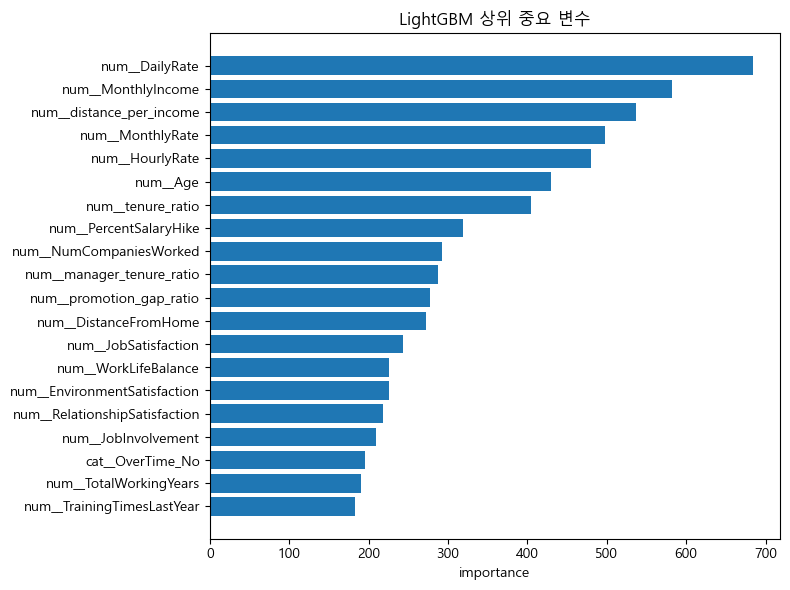

In [11]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 6))
top20 = importance_df.head(20).sort_values("importance")
plt.barh(top20["feature"], top20["importance"])
plt.title("LightGBM 상위 중요 변수")
plt.xlabel("importance")
plt.tight_layout()
plt.show()

LightGBM baseline 모델 메모

- 로지스틱 회귀에서 확인된 중복 변수 문제를 줄이기 위해, 원본 범주형 변수와 의미가 겹치는 일부 이진 파생변수는 제거 후 모델 학습
- LightGBM은 비선형 관계와 변수 간 상호작용을 반영할 수 있어, 로지스틱 회귀 대비 예측력 개선 가능성을 확인하기 위한 baseline 모델로 사용
- 이 단계의 목적 : HR 이직 리스크를 더 잘 순위화할 수 있는지와 주요 중요 변수 확인
- 이후 단계에서는 AutoML을 이용해 모델 후보군을 넓히고, 최종적으로는 explainability와 HR 개입 우선순위 관점으로 연결할 예정